IMPORTACION DE LAS LIBRERIAS


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt


DATASET

el dataset es el de  weatherHistory  contiene datos meteorológicos, como temperatura, humedad, viento y otras variables del clima

In [2]:
data = pd.read_csv('./weatherHistory.csv')

In [3]:
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


PREPROCESAMIENTO


en esta parte trabajaremos primero con la columna de las fechas el cual lo estamos convirtiendo a una tipo de datos de DateTime  



In [5]:
data['Formatted Date'] = pd.to_datetime(data['Formatted Date'], errors='coerce', utc=True)
data = data.dropna(subset=['Formatted Date'])
data['Formatted Date'] = data['Formatted Date'].dt.tz_convert(None)
data.index = pd.DatetimeIndex(data['Formatted Date'])

seleccionamos las columas en la varibale feature  

despues lo convertimos a promedios diarios es decir que si la fecha este en segundo o horas entonces lo convertimos a dias

In [6]:
features = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
            'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
            'Loud Cover', 'Pressure (millibars)']

data_daily = data[features].resample('D').mean()
data_daily = data_daily.interpolate(method='time').ffill().bfill()

en esta seccion es donde normalizamos en un rango de 0 y 1 con MinMaxScaler  
asi dejandolo listo para el modelo

In [7]:
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_daily), columns=features, index=data_daily.index)


todo esto es una secuencia  
es decir miro 30 días de clima y le enseño a la red a adivinar la temperatura del día 31

In [8]:
SEQ_LEN = 30
X, y = [], []
values = data_scaled.values
target_idx = 0 

for i in range(len(values) - SEQ_LEN):
    X.append(values[i:i+SEQ_LEN].flatten())  
    y.append(values[i+SEQ_LEN, target_idx])

X = np.array(X)
y = np.array(y)
print("X.shape:", X.shape)  
print("y.shape:", y.shape)

X.shape: (3989, 240)
y.shape: (3989,)


divicion de datos de prueva con 20% y de entrenamiento con 80%

In [9]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


creacion ya de la red neuronal en este caso tenemos una red con los datos de entrada , con 3 capas ocultas

In [10]:
class RedNeuronal(nn.Module):
    def __init__(self, input_size=SEQ_LEN*len(features), h1=500, h2=250, h3=75, out=1):
        super(RedNeuronal, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, out)
        )
        
    def forward(self, x):
        return self.model(x)

model = RedNeuronal()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

ENTREANMIENTO  
aqui entrenamos el modelo con las epocas que se tien y sacando la precicion tanto del test como del entrenamiento  
estamos usando r2_score para eso mismo

In [11]:
from sklearn.metrics import r2_score

EPOCHS = 200
for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test_t)
            val_loss = criterion(val_pred, y_test_t)
            
          
            train_r2 = r2_score(y_train_t.numpy(), y_pred.numpy()) * 100
            val_r2 = r2_score(y_test_t.numpy(), val_pred.numpy()) * 100
            
        print(f"Epoch {epoch}/{EPOCHS} | "
              f"Train Loss: {loss.item():.5f} | Val Loss: {val_loss.item():.5f} | "
              f"Train %: {train_r2:.2f}% | Val %: {val_r2:.2f}%")


Epoch 20/200 | Train Loss: 0.01751 | Val Loss: 0.01160 | Train %: 50.72% | Val %: 63.81%
Epoch 40/200 | Train Loss: 0.00809 | Val Loss: 0.00615 | Train %: 77.25% | Val %: 80.81%
Epoch 60/200 | Train Loss: 0.00729 | Val Loss: 0.00539 | Train %: 79.50% | Val %: 83.17%
Epoch 80/200 | Train Loss: 0.00657 | Val Loss: 0.00507 | Train %: 81.52% | Val %: 84.18%
Epoch 100/200 | Train Loss: 0.00569 | Val Loss: 0.00457 | Train %: 83.98% | Val %: 85.75%
Epoch 120/200 | Train Loss: 0.00468 | Val Loss: 0.00407 | Train %: 86.83% | Val %: 87.29%
Epoch 140/200 | Train Loss: 0.00398 | Val Loss: 0.00412 | Train %: 88.80% | Val %: 87.15%
Epoch 160/200 | Train Loss: 0.00356 | Val Loss: 0.00361 | Train %: 89.98% | Val %: 88.75%
Epoch 180/200 | Train Loss: 0.00326 | Val Loss: 0.00338 | Train %: 90.84% | Val %: 89.46%
Epoch 200/200 | Train Loss: 0.00306 | Val Loss: 0.00362 | Train %: 91.38% | Val %: 88.71%


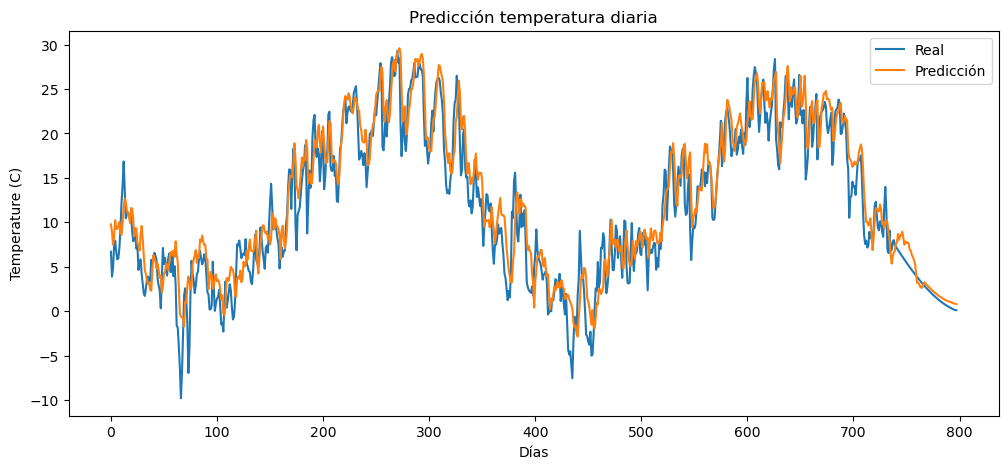

In [12]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t).numpy()

# Revertir escala
y_pred_test_rescaled = scaler.inverse_transform(
    np.hstack([y_pred_test, np.zeros((y_pred_test.shape[0], len(features)-1))])
)[:,0]

y_test_rescaled = scaler.inverse_transform(
    np.hstack([y_test_t.numpy(), np.zeros((y_test_t.shape[0], len(features)-1))])
)[:,0]

plt.figure(figsize=(12,5))
plt.plot(y_test_rescaled, label='Real')
plt.plot(y_pred_test_rescaled, label='Predicción')
plt.title('Predicción temperatura diaria')
plt.xlabel('Días')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11452\2188725374.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  seq_tensor = torch.tensor([last_seq.flatten()], dtype=torch.float32)


            Predicted Temperature (C)
2017-01-01                   0.776383
2017-01-02                   0.854218
2017-01-03                   0.914364
2017-01-04                   0.961410
2017-01-05                   0.982305
2017-01-06                   1.016423
2017-01-07                   1.027363
2017-01-08                   1.040483
2017-01-09                   1.055632
2017-01-10                   1.066798
2017-01-11                   1.077997
2017-01-12                   1.082544
2017-01-13                   1.088039
2017-01-14                   1.080626
2017-01-15                   1.082580
2017-01-16                   1.081393
2017-01-17                   1.069589
2017-01-18                   1.070818
2017-01-19                   1.075070
2017-01-20                   1.074760
2017-01-21                   1.072639
2017-01-22                   1.082212
2017-01-23                   1.083155
2017-01-24                   1.072516
2017-01-25                   1.064590
2017-01-26  

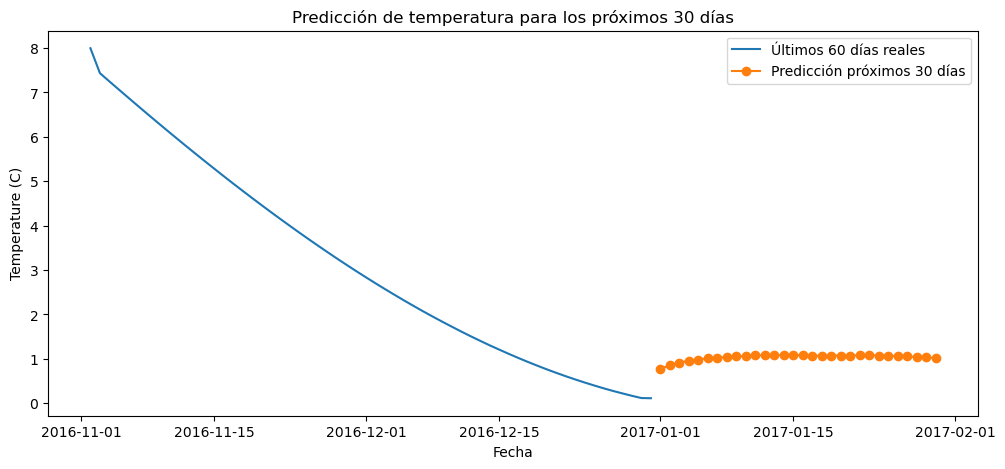

In [13]:
model.eval()
last_seq = data_scaled.values[-SEQ_LEN:].copy()  
future_preds = []

for i in range(30):
    seq_tensor = torch.tensor([last_seq.flatten()], dtype=torch.float32)
    with torch.no_grad():
        pred = model(seq_tensor).item()
    future_preds.append(pred)
    
    
    new_row = last_seq[-1].copy()
    new_row[0] = pred  
    last_seq = np.vstack([last_seq[1:], new_row])  


future_preds_rescaled = scaler.inverse_transform(
    np.hstack([np.array(future_preds).reshape(-1,1), np.zeros((30,len(features)-1))])
)[:,0]

future_dates = pd.date_range(data_daily.index[-1]+pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'Predicted Temperature (C)': future_preds_rescaled}, index=future_dates)
print(future_df)


plt.figure(figsize=(12,5))
plt.plot(data_daily.index[-60:], data_daily['Temperature (C)'].values[-60:], label='Últimos 60 días reales')
plt.plot(future_df.index, future_df['Predicted Temperature (C)'], label='Predicción próximos 30 días', marker='o')
plt.title('Predicción de temperatura para los próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()